#***HR Attrition Prediction***

**🧠 Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.
In this project, the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:
● Age
● Salary
● Job Role
● Job Satisfaction
● Work Experience
● Overtime
● Work-Life Balance
● Department






#***🎯 Objective***

The objective of this task is to:
● Understand and explore the HR dataset
● Perform data preprocessing (missing values, duplicates, outliers)
● Conduct Exploratory Data Analysis (EDA)
● Apply encoding and feature scaling
● Train multiple classification algorithms
● Evaluate models using classification metrics
● Perform cross-validation and hyperparameter tuning
● Select the best-performing model

#**📌 Tasks**

In [4]:
#import all required libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_csv('HR-Employee-Attrition.csv')

In [6]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
df.shape

(1470, 35)

In [8]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [12]:
df.duplicated().sum()

np.int64(0)

### <span style="color: #1a73e8;">Data Preprocessing</span>

In [13]:
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], inplace=True)
df.shape

(1470, 31)

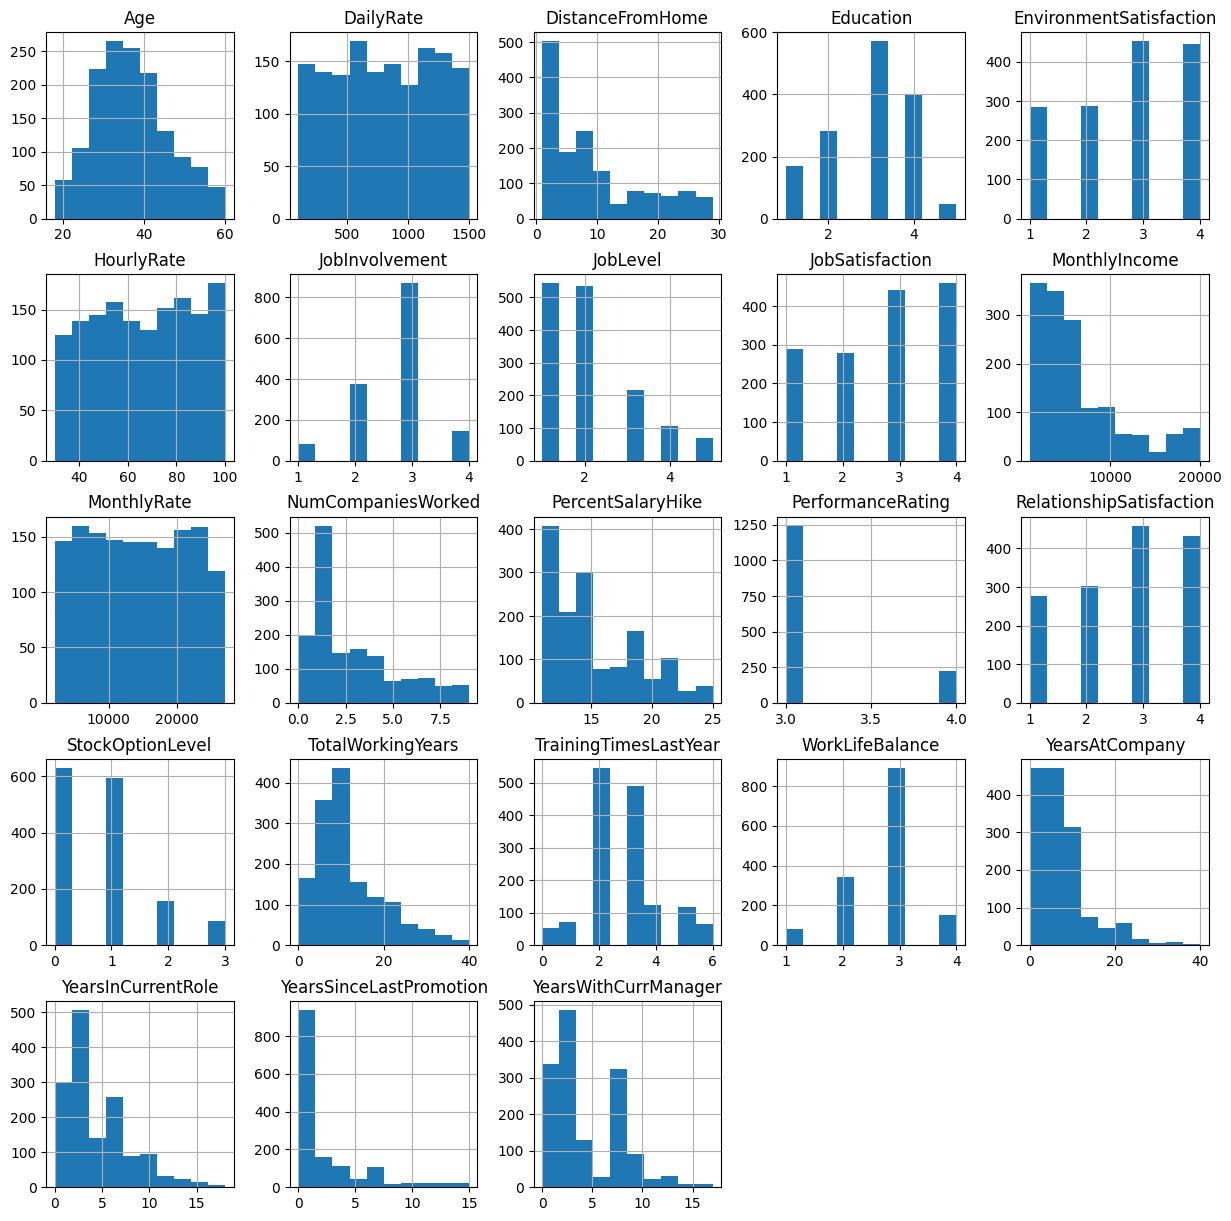

In [17]:
df.hist(figsize=(15,15))
plt.show()

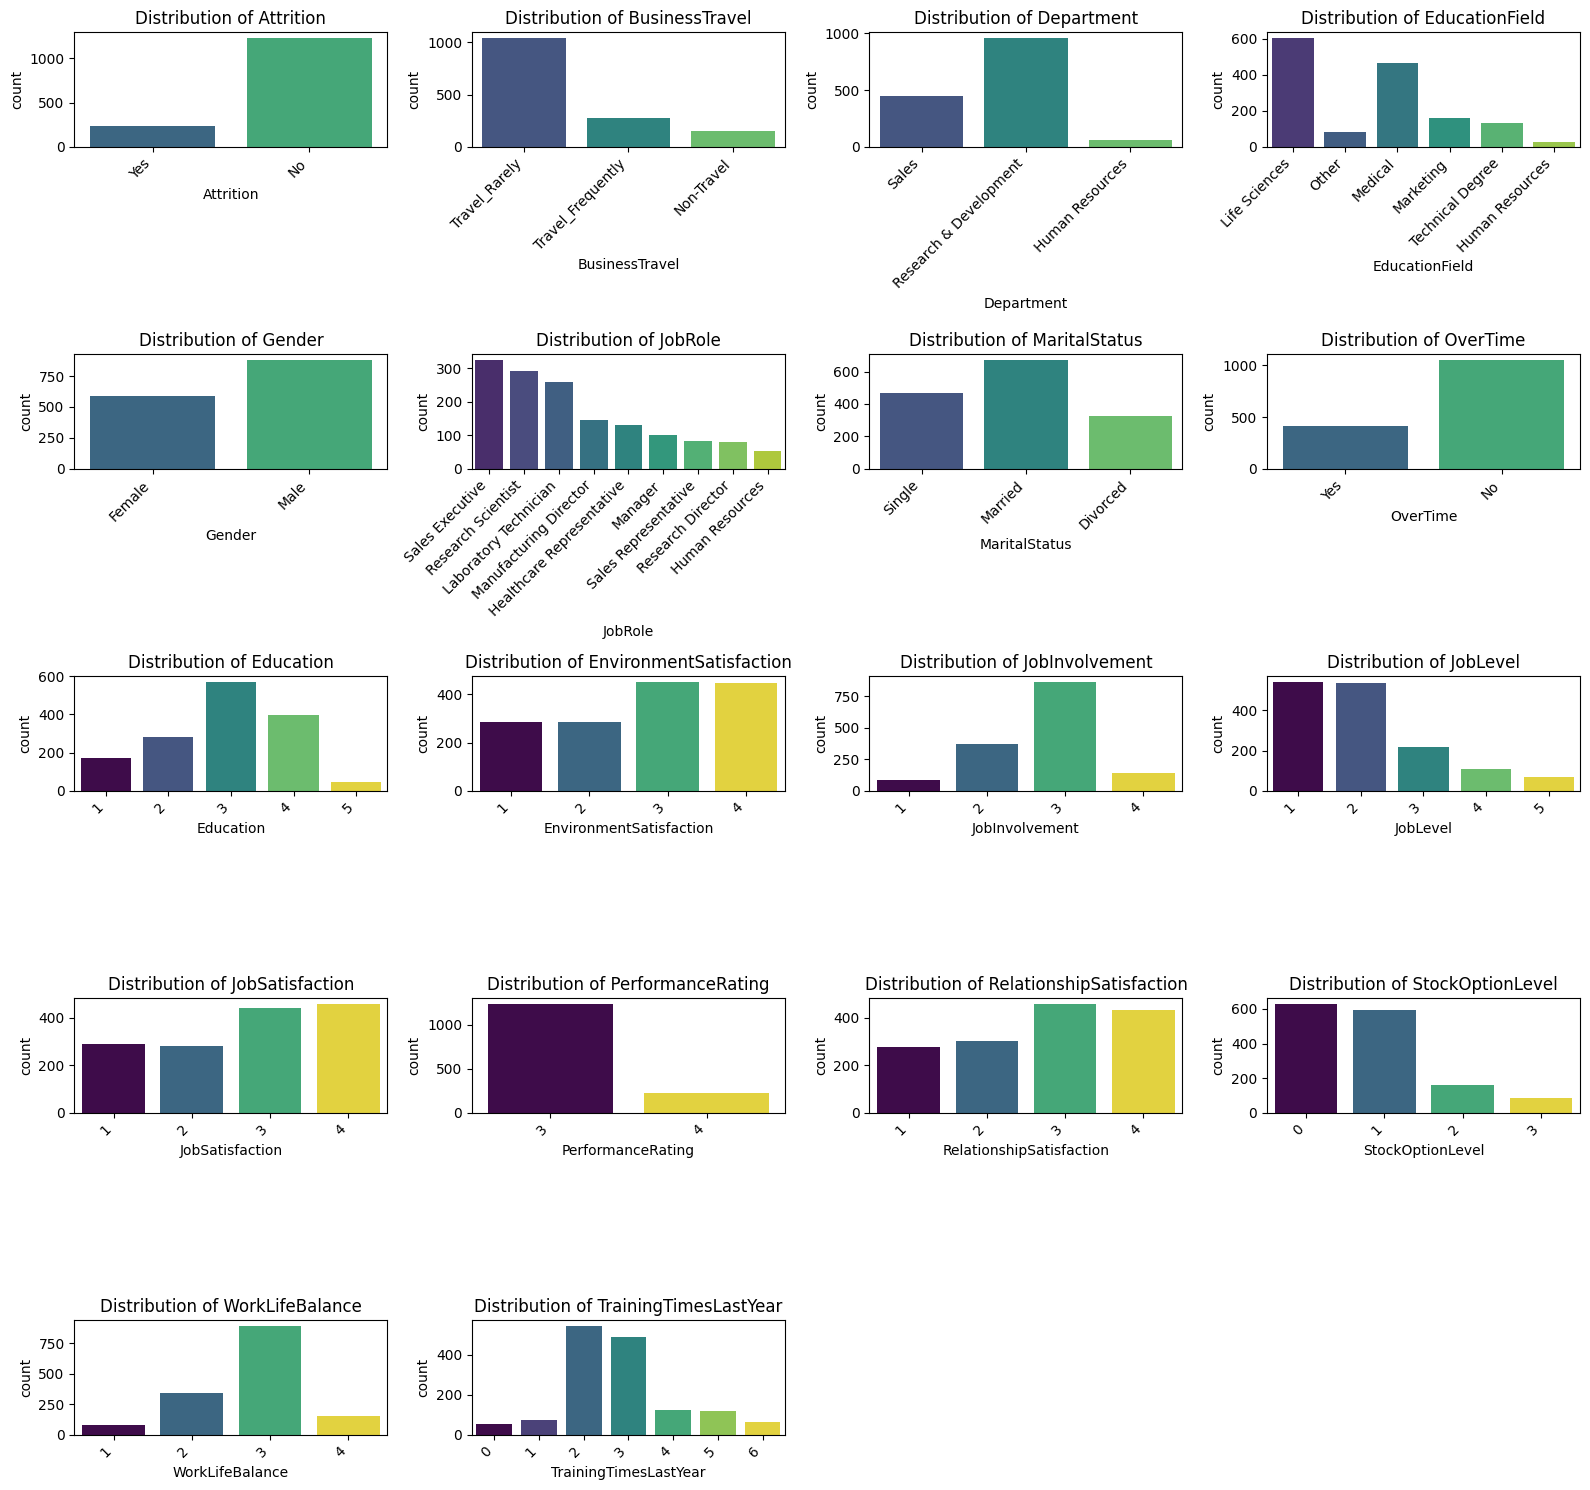

In [26]:


categorical_cols = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
    'JobRole', 'MaritalStatus', 'OverTime', 'Education',
    'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
    'WorkLifeBalance', 'TrainingTimesLastYear'
]

# Determine the number of rows and columns for the subplots
num_cols = 4
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 4, num_rows * 3))

for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

In [19]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### <span style="color: #1a73e8;">Bivariate Analysis: Attrition vs. Categorical Features</span>

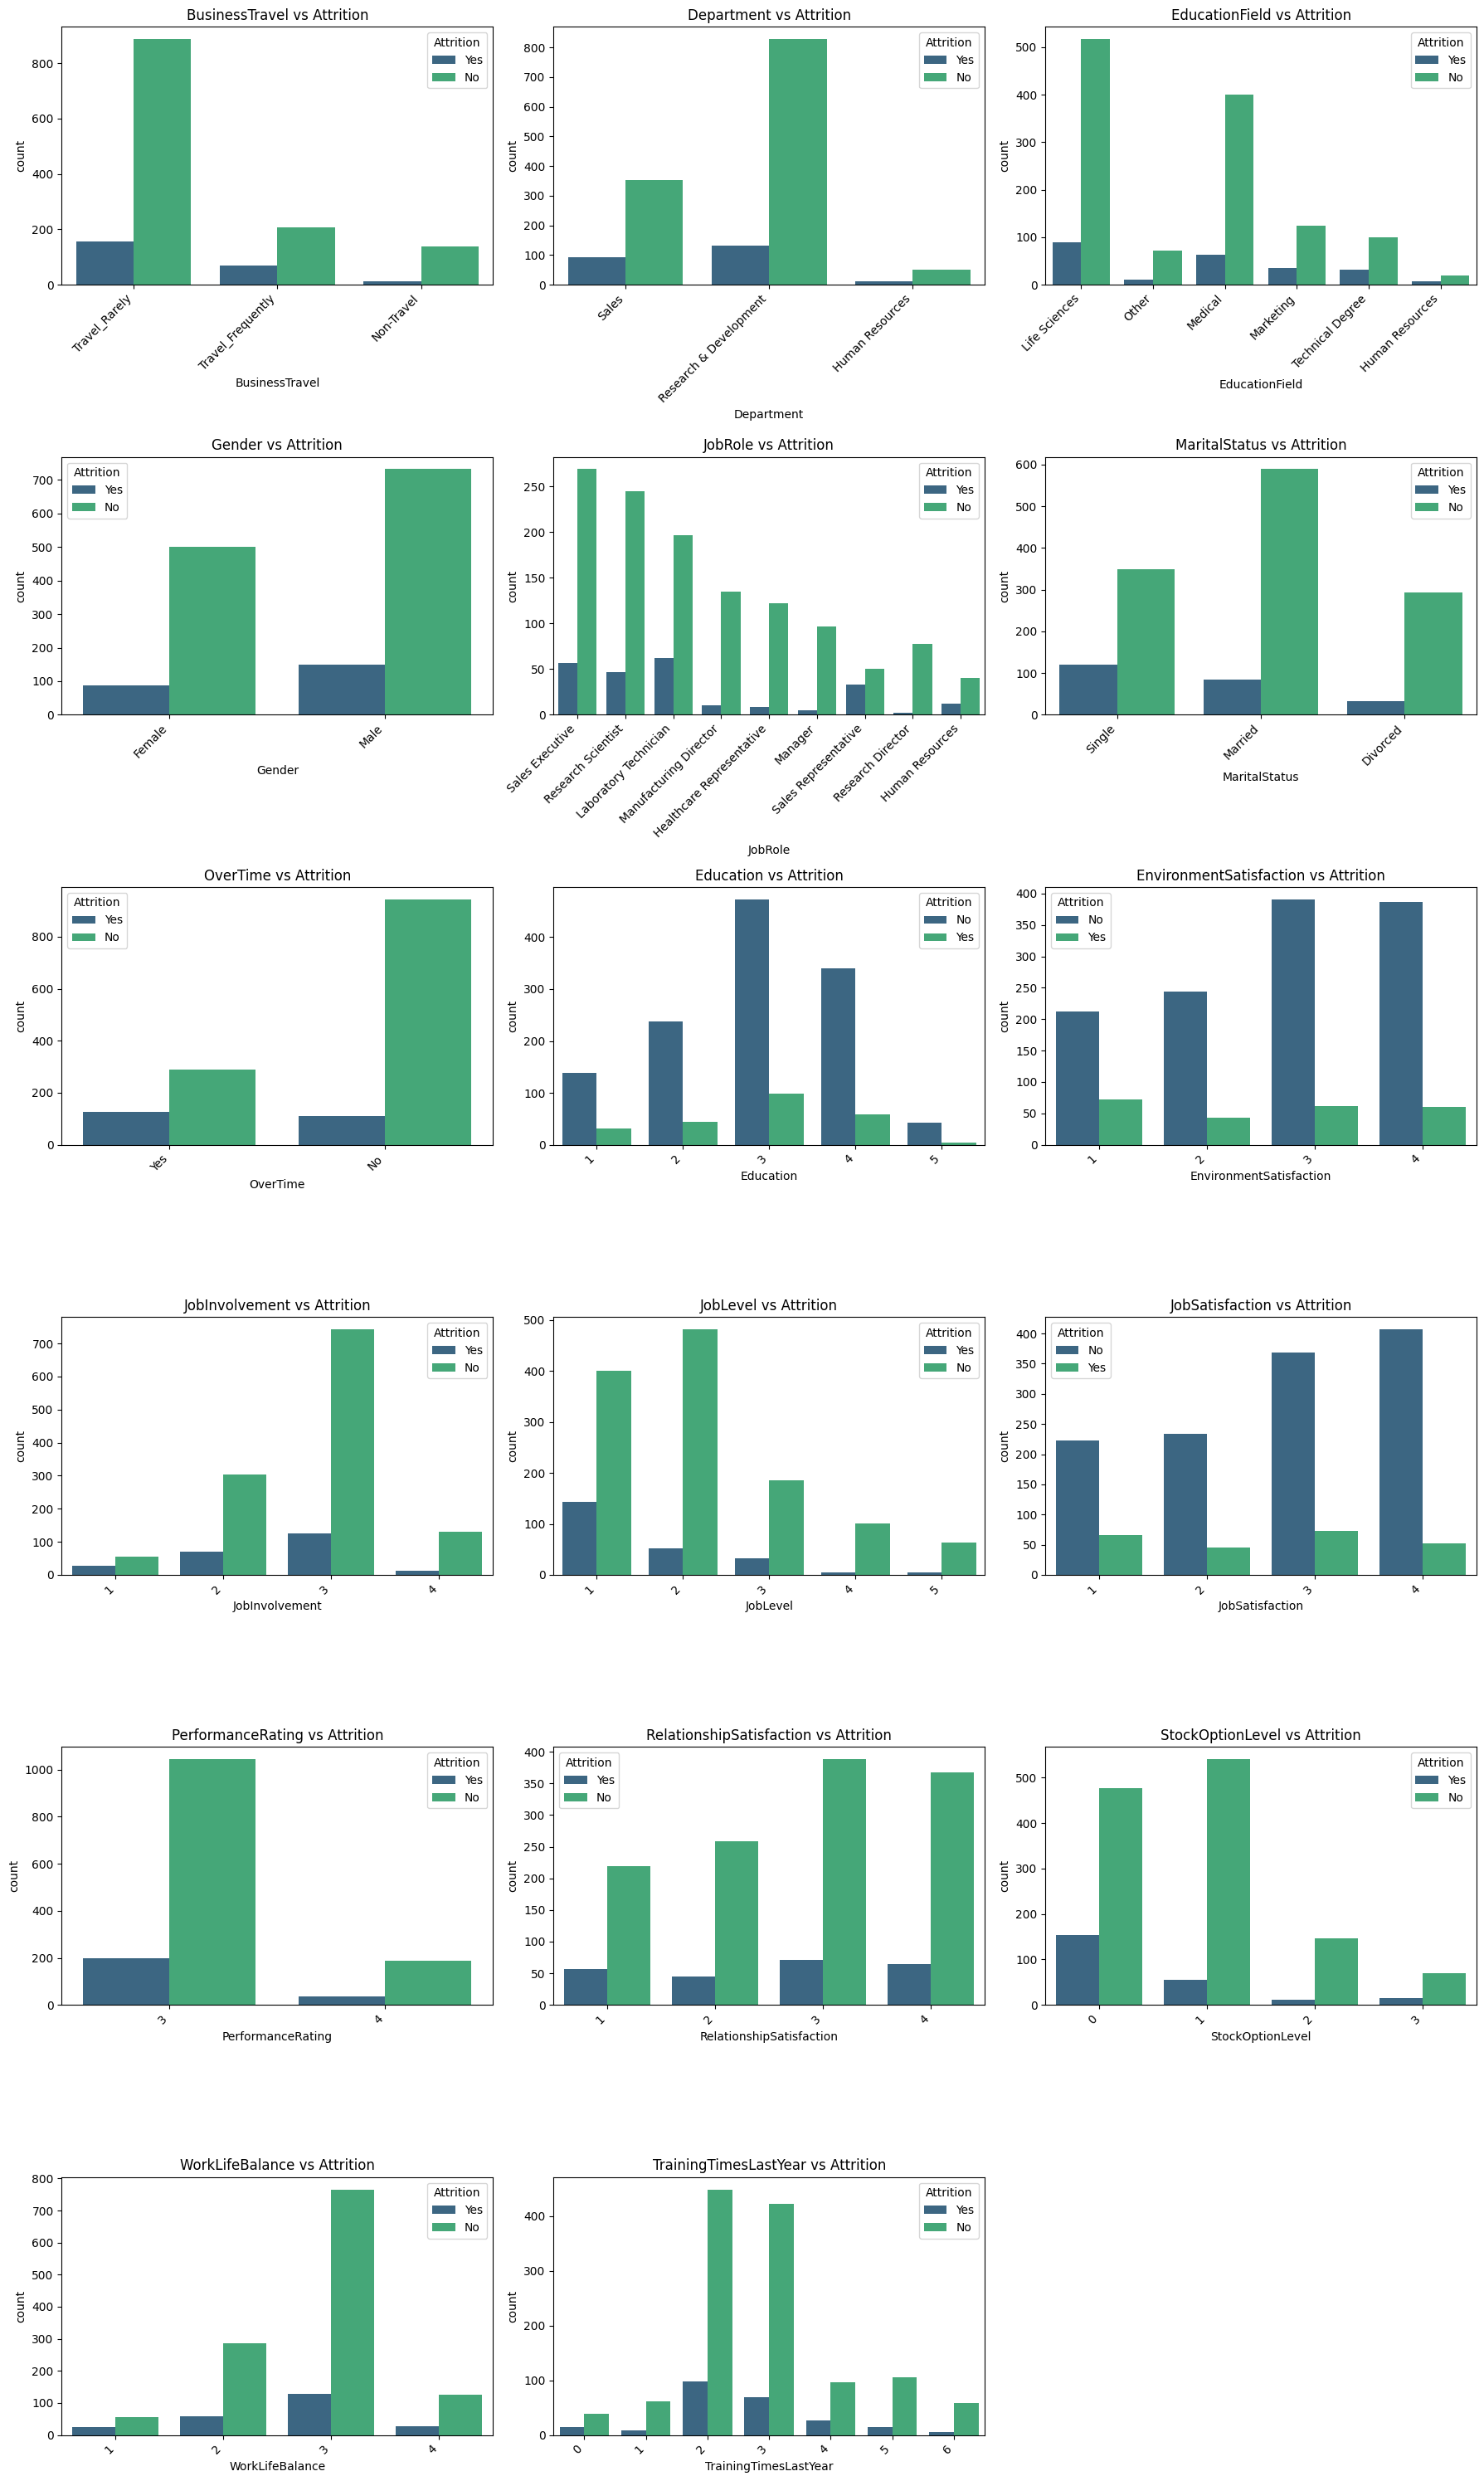

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_bivariate = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
    'MaritalStatus', 'OverTime', 'Education', 'EnvironmentSatisfaction',
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance',
    'TrainingTimesLastYear'
]

num_cols = 3
num_rows = (len(categorical_features_bivariate) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(categorical_features_bivariate):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.countplot(x=col, hue='Attrition', data=df, palette='viridis')
    plt.title(f'{col} vs Attrition')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

plt.show()

### <span style="color: #1a73e8;">Bivariate Analysis: Attrition vs. Numerical Features</span>

/tmp/ipykernel_13710/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
/tmp/ipykernel_13710/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
/tmp/ipykernel_13710/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
/tmp/ipykernel_13710/2040313498.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

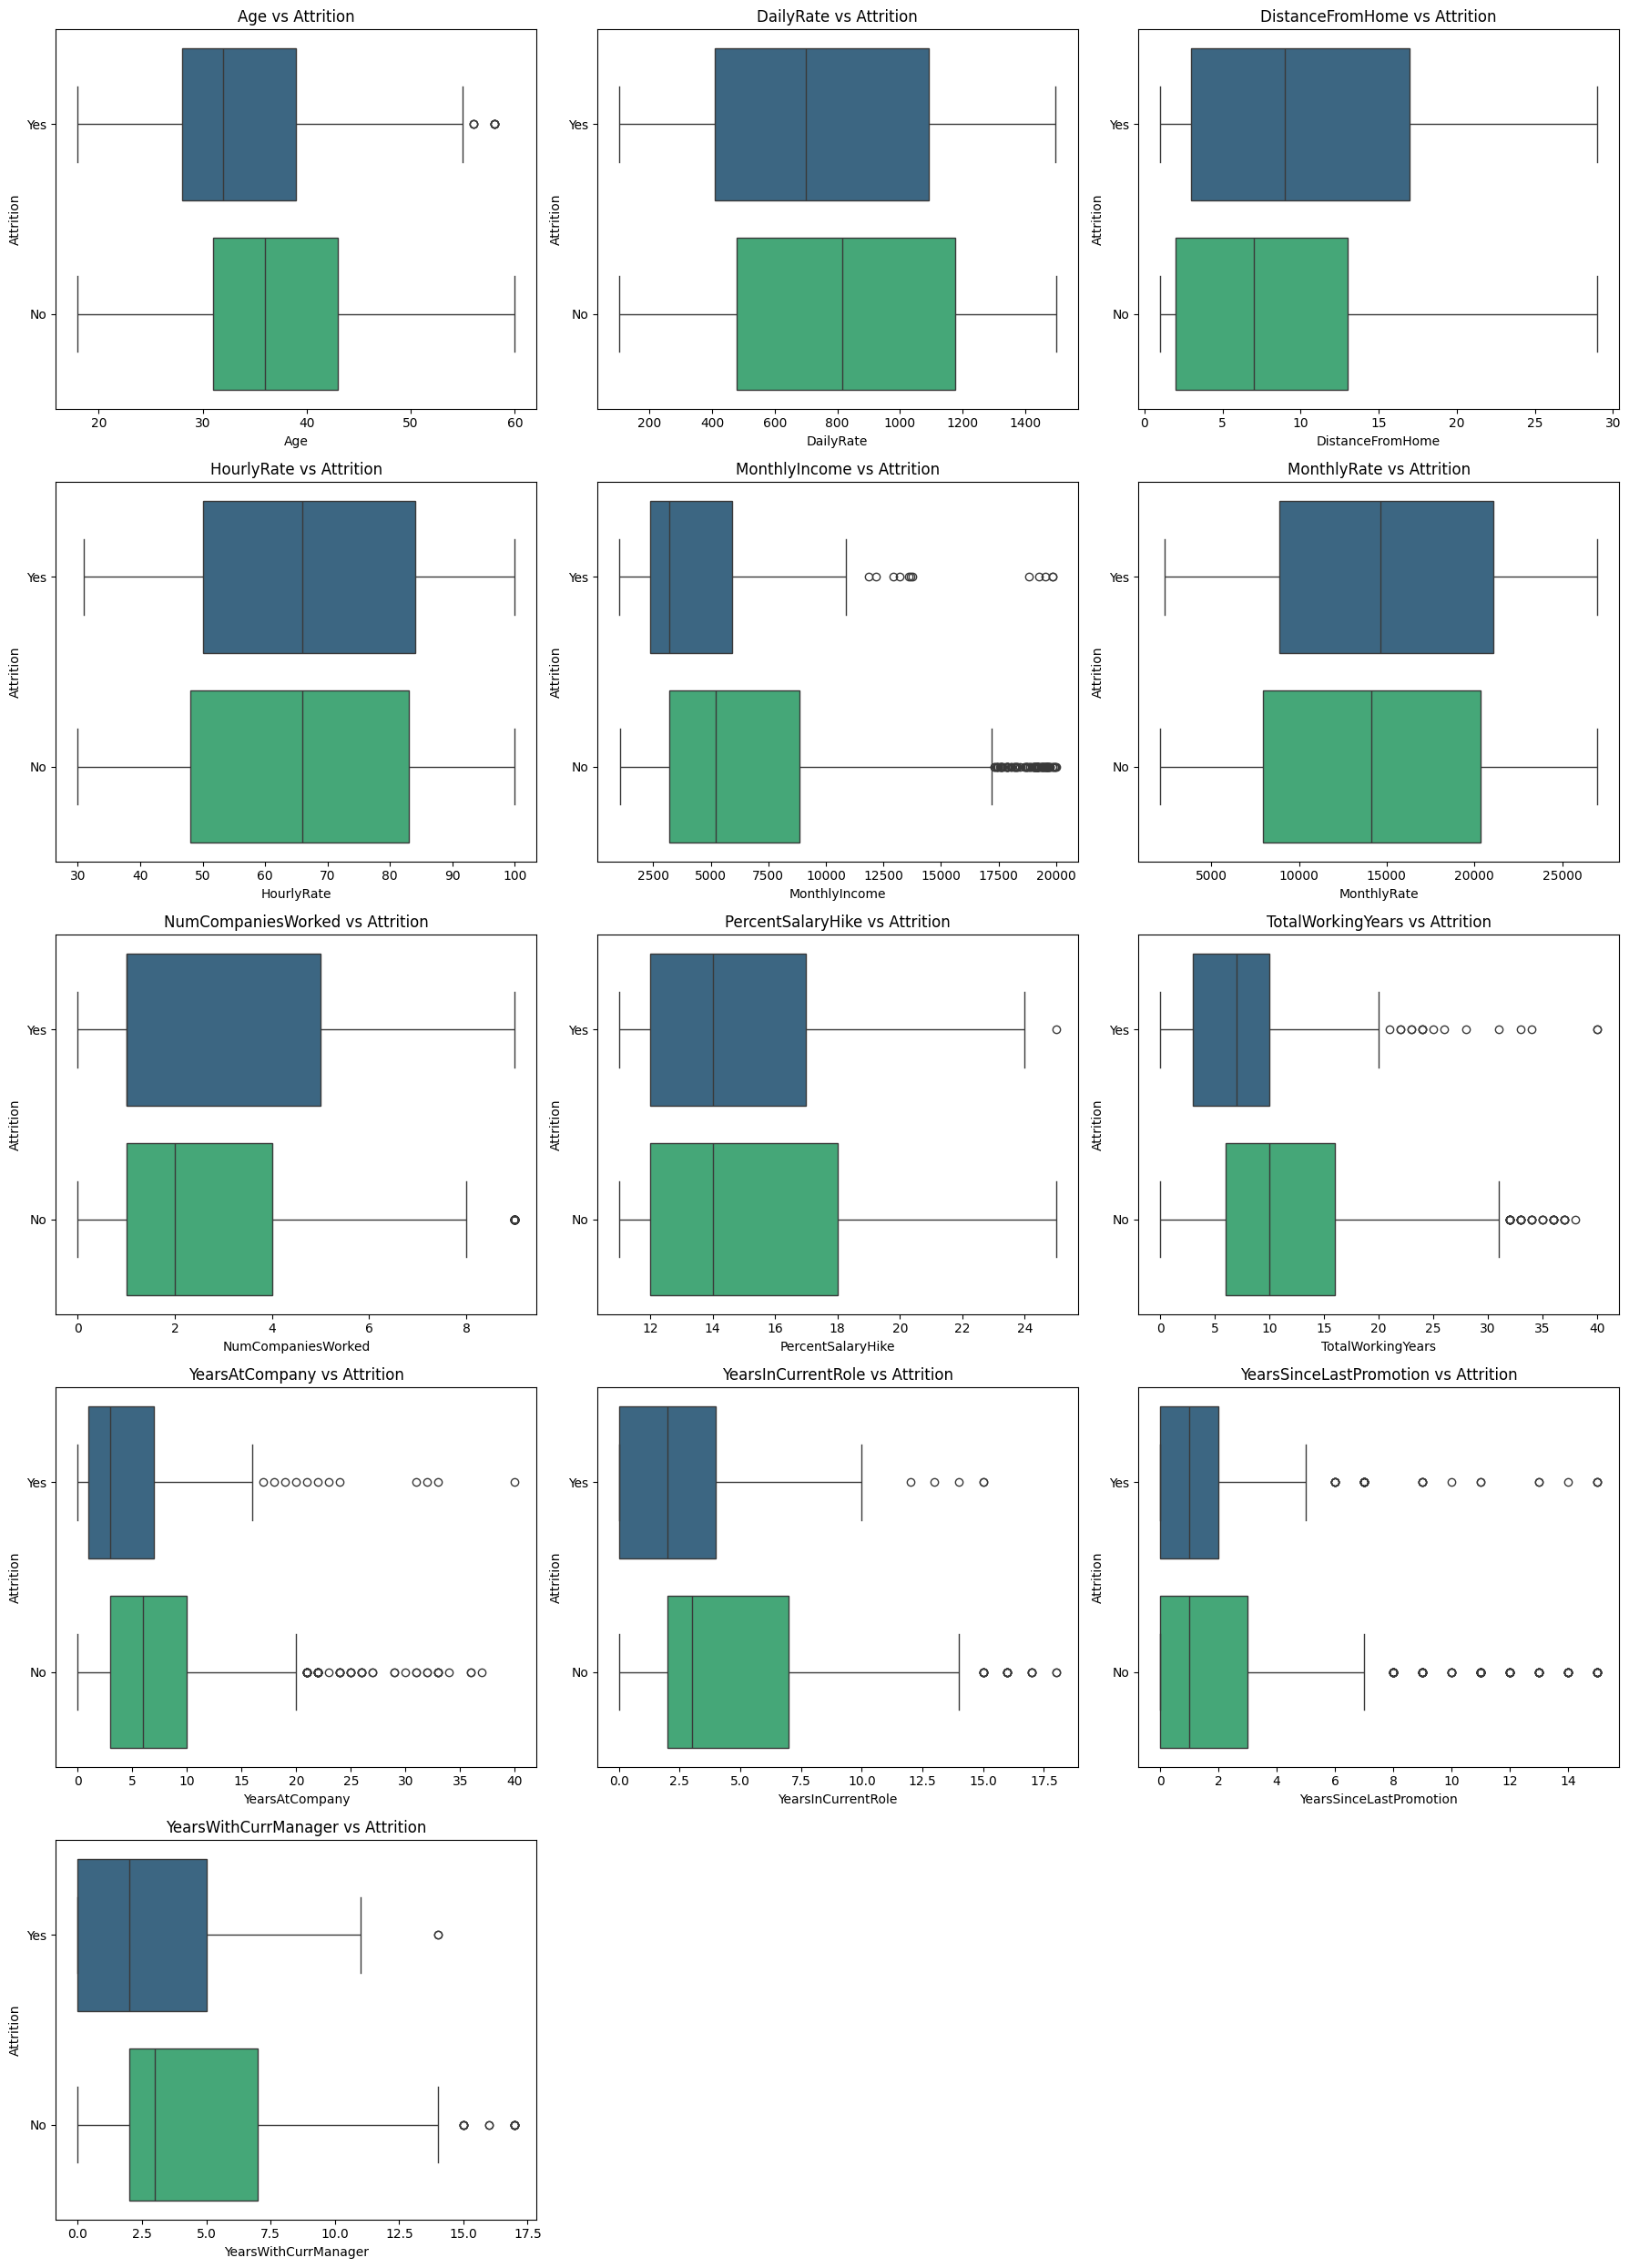

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical features for bivariate analysis
numerical_features_bivariate = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Determine the number of rows and columns for the subplots
num_cols = 3
num_rows = (len(numerical_features_bivariate) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 5))

for i, col in enumerate(numerical_features_bivariate):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y='Attrition', x=col, data=df, palette='viridis')
    plt.title(f'{col} vs Attrition')
    plt.xticks(rotation=0)
    plt.tight_layout()

plt.show()

### <span style="color: #1a73e8;">Outlier Handling for All Numerical Features using IQR Method</span>

### <span style="color: #1a73e8;">Correlation Heatmap</span>

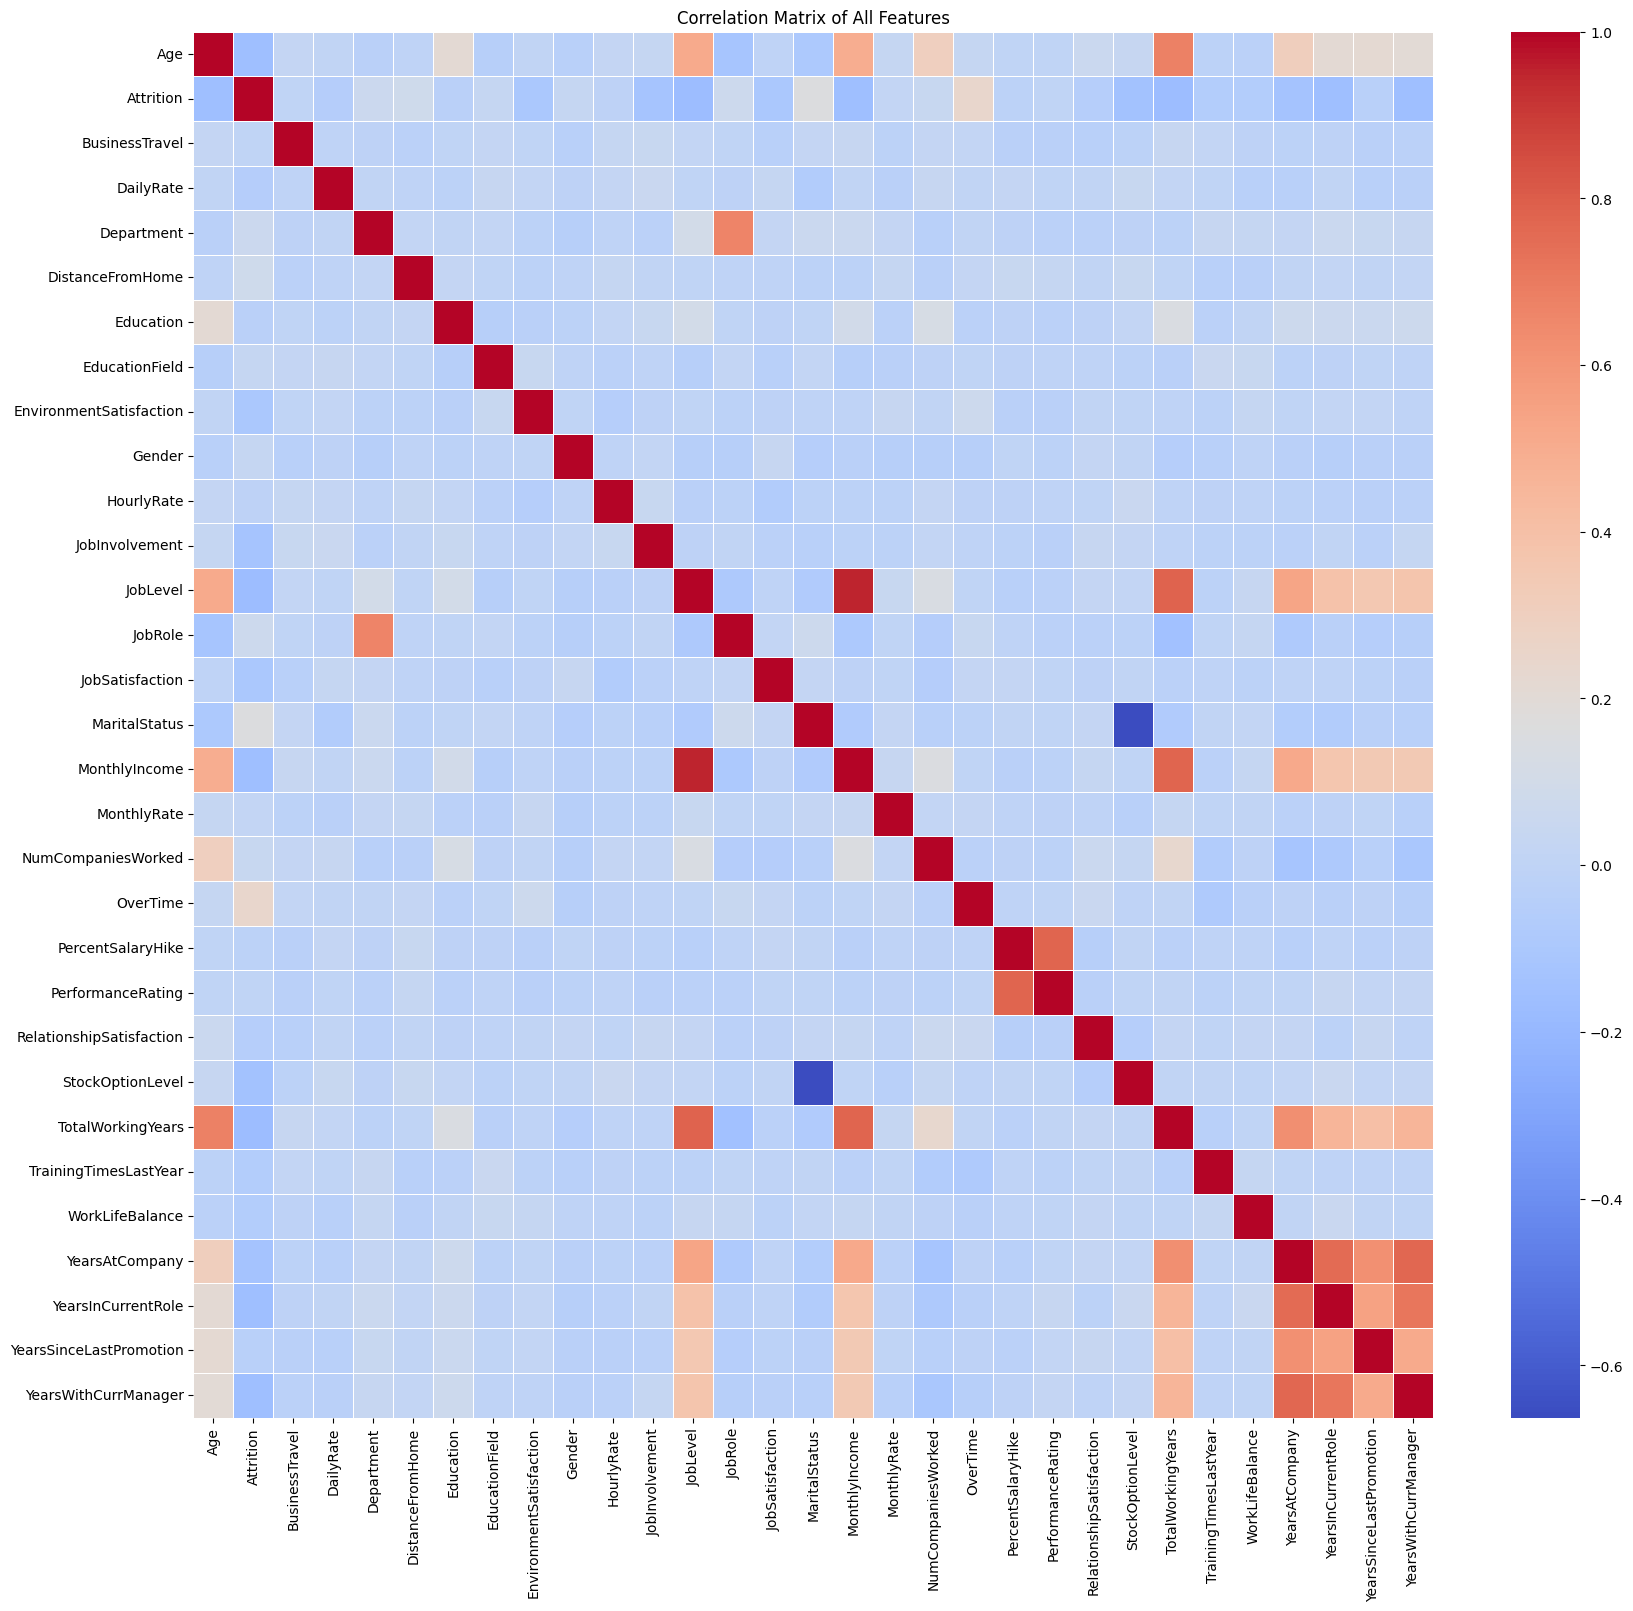

In [35]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Apply Label Encoding to all object type columns
for column in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Features')
plt.show()

### <span style="color: #1a73e8;">Outlier Detection using Box Plots</span>

/tmp/ipykernel_13710/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_13710/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_13710/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='viridis')
/tmp/ipykernel_13710/2055707025.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

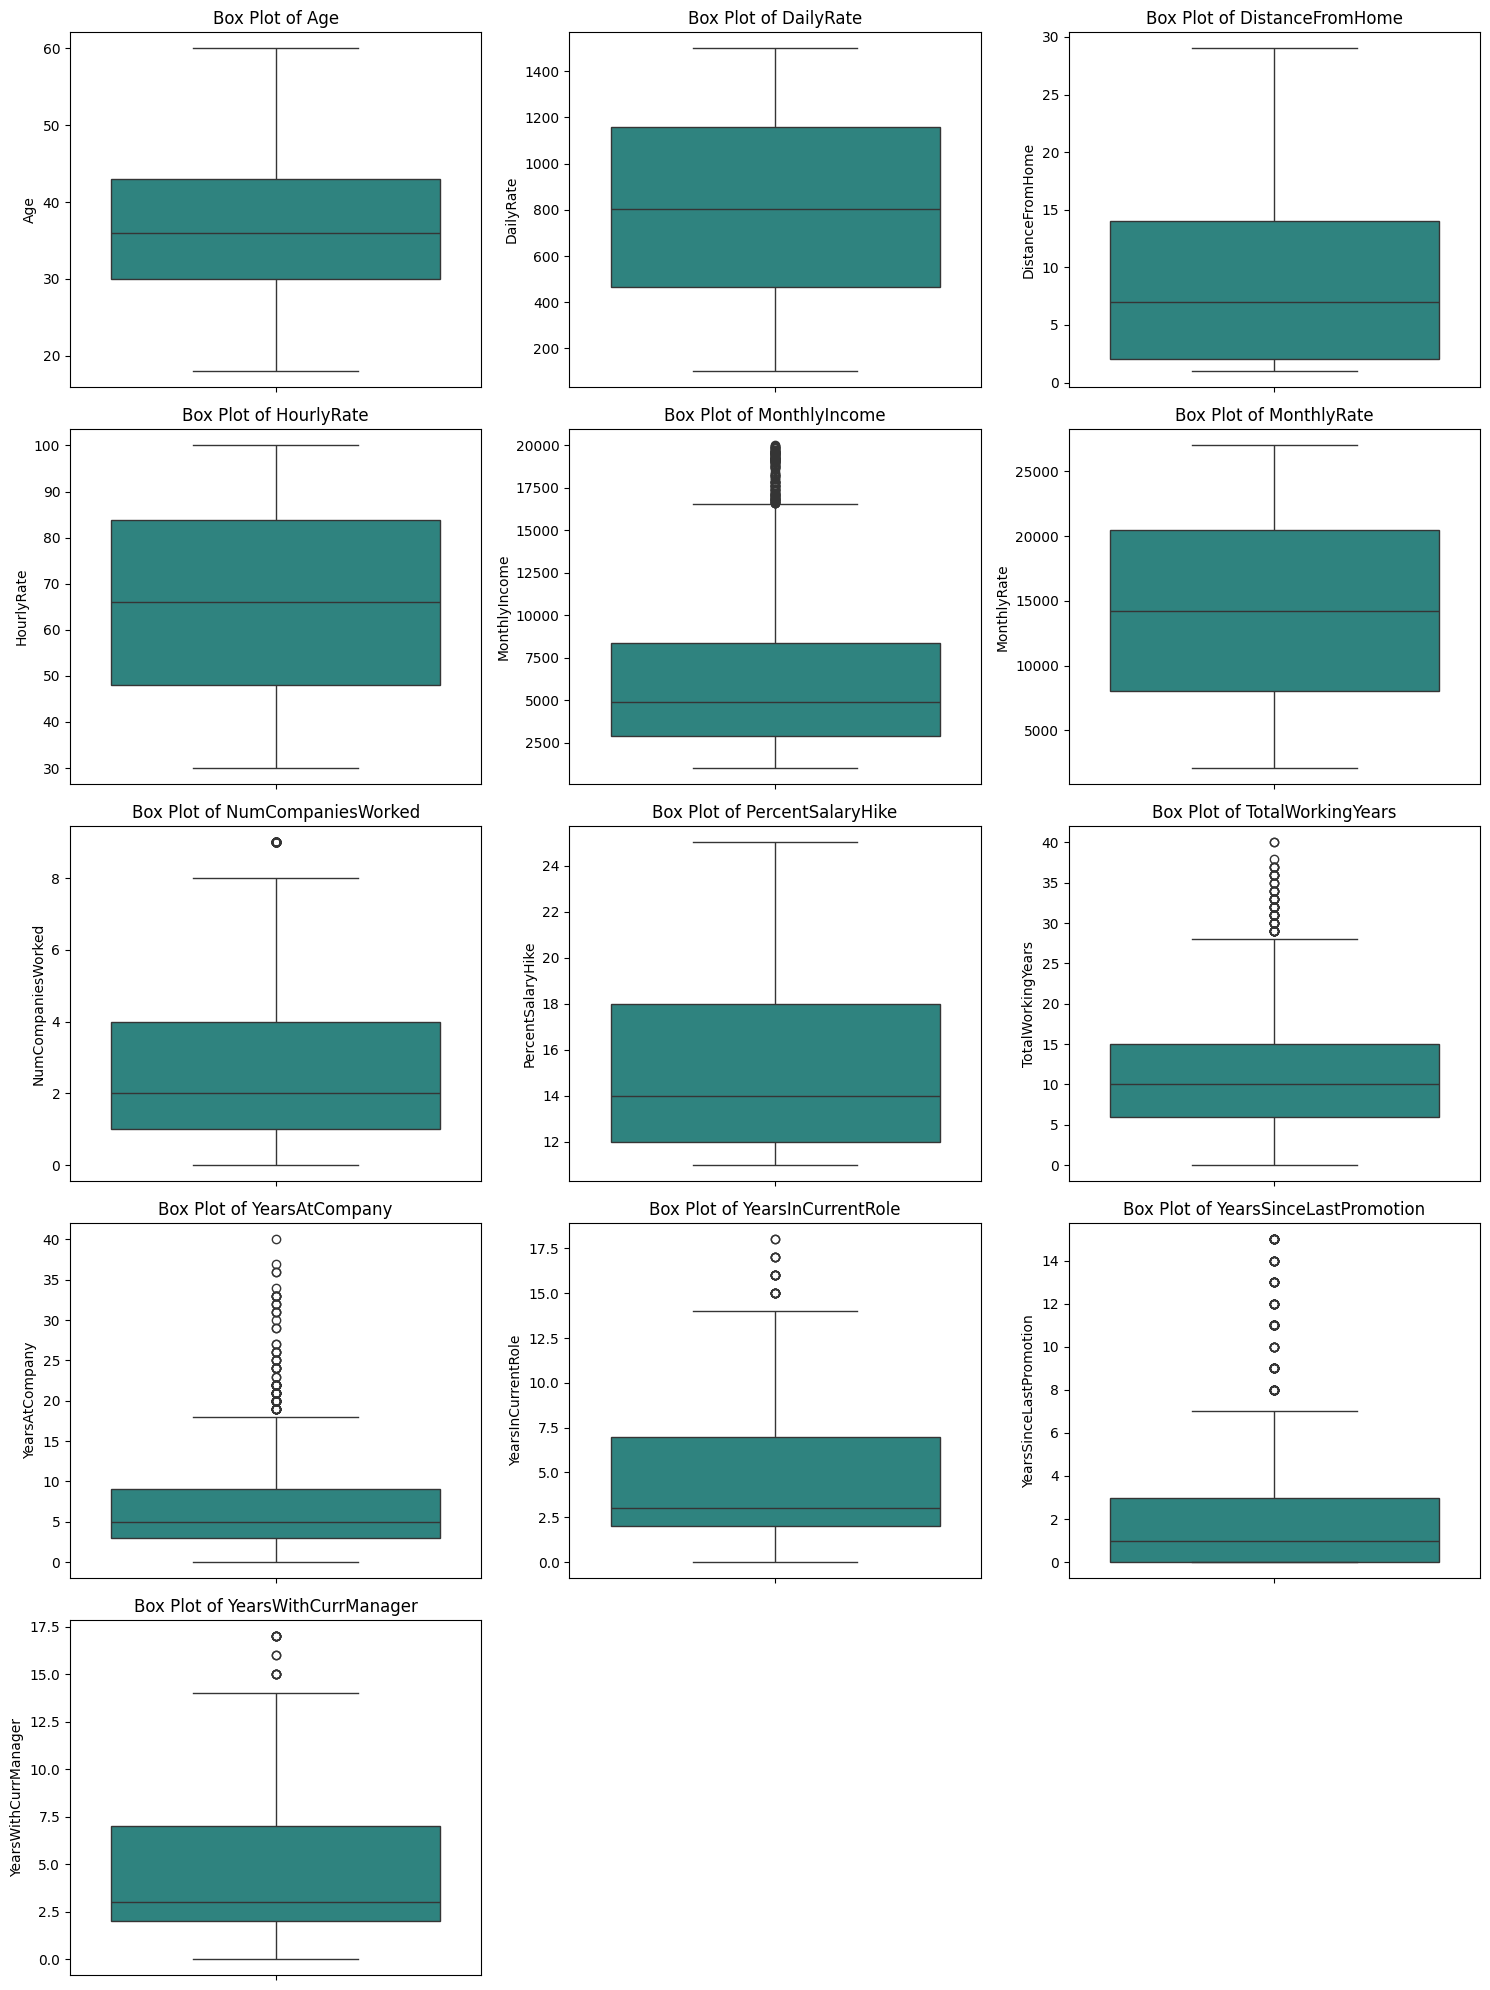

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols_for_outliers = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude columns that are actually categorical but encoded as numbers (e.g., JobLevel, Education)
# Based on df.info() and df.describe() in previous cells, some integer columns represent categories.
# I'll manually select columns that are truly numerical and might have outliers.
numerical_cols_for_outliers_filtered = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Determine the number of rows and columns for the subplots
num_cols = 3
num_rows = (len(numerical_cols_for_outliers_filtered) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(numerical_cols_for_outliers_filtered):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df[col], palette='viridis')
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()

plt.show()

### <span style="color: #1a73e8;">Outlier Handling using IQR Method (Example: MonthlyIncome)</span>

We can use the Interquartile Range (IQR) method to cap outliers. Values below Q1 - 1.5 * IQR are replaced by the lower bound, and values above Q3 + 1.5 * IQR are replaced by the upper bound. Let's apply this to 'MonthlyIncome' as an example.

Original range for MonthlyIncome: [1009, 19999]
IQR bounds: [-5291.0, 16581.0]
Range after outlier capping for MonthlyIncome: [1009.0, 16581.0]


/tmp/ipykernel_13710/1795340547.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_no_outliers[column_to_handle], palette='viridis')


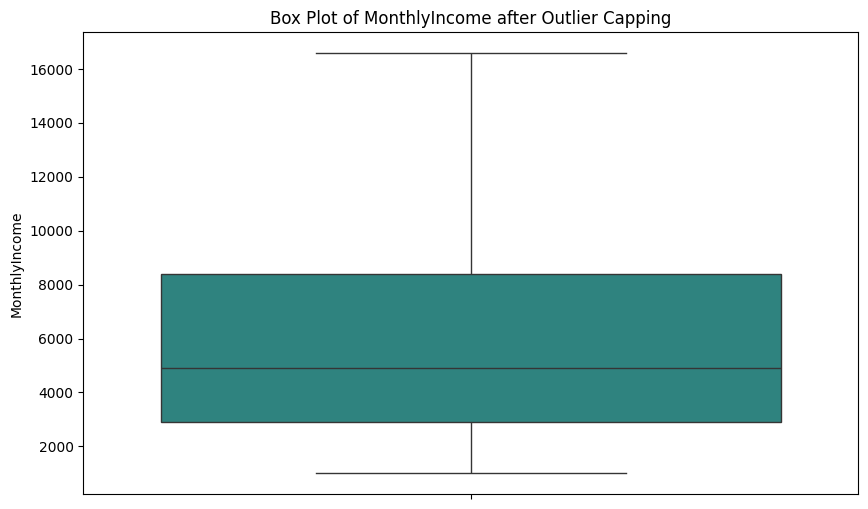

In [32]:
import numpy as np

# Choose a column to demonstrate outlier handling
column_to_handle = 'MonthlyIncome'

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[column_to_handle].quantile(0.25)
Q3 = df[column_to_handle].quantile(0.75)
IQR = Q3 - Q1

# Define the upper and lower bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Original range for {column_to_handle}: [{df[column_to_handle].min()}, {df[column_to_handle].max()}]")
print(f"IQR bounds: [{lower_bound}, {upper_bound}]")

# Create a new column or modify the existing one to handle outliers
df_no_outliers = df.copy()
df_no_outliers[column_to_handle] = np.where(
    df_no_outliers[column_to_handle] < lower_bound, lower_bound,
    np.where(df_no_outliers[column_to_handle] > upper_bound, upper_bound,
             df_no_outliers[column_to_handle]
    )
)

print(f"Range after outlier capping for {column_to_handle}: [{df_no_outliers[column_to_handle].min()}, {df_no_outliers[column_to_handle].max()}]")

# Visualize the distribution after outlier handling
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_no_outliers[column_to_handle], palette='viridis')
plt.title(f'Box Plot of {column_to_handle} after Outlier Capping')
plt.show()

In [34]:
import numpy as np

df_cleaned = df.copy()

# List of numerical columns identified for outlier handling
numerical_cols_to_clean = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

print("Outlier capping summary for each numerical column:")

for col in numerical_cols_to_clean:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers_before = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]

    # Apply capping
    df_cleaned[col] = np.where(
        df_cleaned[col] < lower_bound, lower_bound,
        np.where(df_cleaned[col] > upper_bound, upper_bound,
                 df_cleaned[col]
        )
    )

    # Count outliers after capping (should be 0 for capped values)
    outliers_after = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]

    print(f"- {col}: Outliers removed: {outliers_before}. New range: [{df_cleaned[col].min():.2f}, {df_cleaned[col].max():.2f}]")

print("\nDataFrame 'df_cleaned' now contains data with outliers capped.")

# Display descriptive statistics for a few cleaned columns to confirm
display(df_cleaned[numerical_cols_to_clean].describe())

Outlier capping summary for each numerical column:
- Age: Outliers removed: 0. New range: [18.00, 60.00]
- DailyRate: Outliers removed: 0. New range: [102.00, 1499.00]
- DistanceFromHome: Outliers removed: 0. New range: [1.00, 29.00]
- HourlyRate: Outliers removed: 0. New range: [30.00, 100.00]
- MonthlyIncome: Outliers removed: 114. New range: [1009.00, 16581.00]
- MonthlyRate: Outliers removed: 0. New range: [2094.00, 26999.00]
- NumCompaniesWorked: Outliers removed: 52. New range: [0.00, 8.50]
- PercentSalaryHike: Outliers removed: 0. New range: [11.00, 25.00]
- TotalWorkingYears: Outliers removed: 63. New range: [0.00, 28.50]
- YearsAtCompany: Outliers removed: 104. New range: [0.00, 18.00]
- YearsInCurrentRole: Outliers removed: 21. New range: [0.00, 14.50]
- YearsSinceLastPromotion: Outliers removed: 107. New range: [0.00, 7.50]
- YearsWithCurrManager: Outliers removed: 14. New range: [0.00, 14.50]

DataFrame 'df_cleaned' now contains data with outliers capped.


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,65.891156,6361.891837,14313.103401,2.675510,15.209524,11.103061,6.617687,4.207823,1.922789,4.107483
std,9.135373,403.509100,8.106864,20.329428,4353.345470,7117.786044,2.454656,3.659938,7.303828,4.989788,3.555335,2.478222,3.517487
min,18.000000,102.000000,1.000000,30.000000,1009.000000,2094.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,48.000000,2911.000000,8047.000000,1.000000,12.000000,6.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,66.000000,4919.000000,14235.500000,2.000000,14.000000,10.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,83.750000,8379.000000,20461.500000,4.000000,18.000000,15.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,100.000000,16581.000000,26999.000000,8.500000,25.000000,28.500000,18.000000,14.500000,7.500000,14.500000


### <span style="color: #1a73e8;">Applying Encoding</span>

In [36]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_encoded = df_cleaned.copy()

# --- Label Encoding for binary or ordinal categorical features ---
label_encode_cols = ['Attrition', 'Gender', 'OverTime']

for col in label_encode_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Label Encoded '{col}': {df_encoded[col].unique()}")

# --- One-Hot Encoding for nominal categorical features ---
one_hot_encode_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'
]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=one_hot_encode_cols, drop_first=True, dtype=int)

print(f"\nDataFrame shape after encoding: {df_encoded.shape}")
print("\nFirst 5 rows of the encoded DataFrame:")
display(df_encoded.head())

Label Encoded 'Attrition': [1 0]
Label Encoded 'Gender': [0 1]
Label Encoded 'OverTime': [1 0]

DataFrame shape after encoding: (1470, 45)

First 5 rows of the encoded DataFrame:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41.0,1,1102.0,1.0,2,2,0,94.0,3,2,...,0,0,0,0,0,0,1,0,0,1
1,49.0,0,279.0,8.0,1,3,1,61.0,2,2,...,0,0,0,0,0,1,0,0,1,0
2,37.0,1,1373.0,2.0,2,4,1,92.0,2,1,...,0,1,0,0,0,0,0,0,0,1
3,33.0,0,1392.0,3.0,4,4,0,56.0,3,1,...,0,0,0,0,0,1,0,0,1,0
4,27.0,0,591.0,2.0,1,1,1,40.0,3,1,...,0,1,0,0,0,0,0,0,1,0


### <span style="color: #1a73e8;">Applying Feature Scaling</span>

In [38]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_scaled = df_encoded.copy()

# Identify numerical columns to scale
# Exclude 'Attrition' (target variable) and already encoded categorical features that are essentially ordinal/nominal
numerical_cols_to_scale = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df_scaled[numerical_cols_to_scale] = scaler.fit_transform(df_scaled[numerical_cols_to_scale])

print("DataFrame shape after scaling:", df_scaled.shape)
print("\nFirst 5 rows of the scaled DataFrame:")
display(df_scaled.head())

DataFrame shape after scaling: (1470, 45)

First 5 rows of the scaled DataFrame:


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.446350,1,0.742527,-1.010909,2,2,0,1.383138,3,2,...,0,0,0,0,0,0,1,0,0,1
1,1.322365,0,-1.297775,-0.147150,1,3,1,-0.240677,2,2,...,0,0,0,0,0,1,0,0,1,0
2,0.008343,1,1.414363,-0.887515,2,4,1,1.284725,2,1,...,0,1,0,0,0,0,0,0,0,1
3,-0.429664,0,1.461466,-0.764121,4,4,0,-0.486709,3,1,...,0,0,0,0,0,1,0,0,1,0
4,-1.086676,0,-0.524295,-0.887515,1,1,1,-1.274014,3,1,...,0,1,0,0,0,0,0,0,1,0


In [37]:
Apply Scaling
● StandardScaler / MinMaxScaler

SyntaxError: invalid character '●' (U+25CF) (3562769353.py, line 2)

### <span style="color: #1a73e8;">Separate Features and Target Variable</span>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df_scaled.drop('Attrition', axis=1)
y = df_scaled['Attrition']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
display(X.head())


### <span style="color: #1a73e8;">Perform Train-Test Split</span>

In [ ]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
